# Classification Using A Tiny Transformer Encoder From Scratch (& Fine-Tuning BERT)

---


## Artin Tavasoli - SID: 810102543 

Ref: the paper uses a 9 step cleaning tweet texts method.

• Case normalization

• Remove emails

• Remove URLs

• Remove HTML tags

• Remove emojis

• Replace abbreviations

• Remove stopwords

• Remove special characters, non-text characters

• Remove repeated punctuations / words

In [1]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
import emoji

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

ABBREVIATIONS = {
    "u": "you",
    "r": "are",
    "ur": "your",
    "im": "i am",
    "dont": "do not",
    "cant": "cannot",
    "wont": "will not",
    "omg": "oh my god",
    "lol": "laughing out loud",
    "smh": "shaking my head",
    "gonna": "going to",
    "wanna": "want to",
    "bc": "because",
    "rn": "right now",
    "lmao": "laughing my ass off",
    "kinda": "kind of",
    "idk": "i do not know",
    "pls": "please",
    "yall": "you all",
    "ill": "i will",
    "didnt": "did not",
    "gotta": "got to",
    "af": "as fuck",
    "wtf": "what the fuck",
    "bout": "about",
    "cuz": "because",
    "btw": "by the way",
    "tbh": "to be honest",
    "doesnt": "does not",
    "fr": "for real",
    "imo": "in my opinion"
}


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**set seed**

we don't want difference results when we run the code multiple times, so we set seed so that the randomness doesn't change

In [2]:
SEED = 42
import random
import os
import numpy as np
import torch
def set_seed(seed):
    random.seed(seed)
    
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [3]:
def check_missing_values(df):

    missing_counts = df.isnull().sum()
    missing_percent = (df.isnull().sum() / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing Values': missing_counts,
        'Percentage (%)': missing_percent
    }).sort_values(by='Percentage (%)', ascending=False)
    
    return missing_df

def clean_tweet_text(text):

    # Case normalization
    text = text.lower()
    
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove emojis 
    text = emoji.replace_emoji(text, replace='')
    
    # Replace abbreviations
    words = text.split()
    words = [ABBREVIATIONS.get(word, word) for word in words]
    text = ' '.join(words)
    
    # Remove special characters, non-text characters
    text = re.sub(r'[^a-zA-Z0-s\s]', ' ', text)
    
    # Remove repeated punctuations / words 
    text = re.sub(r'\b(\w+)( \1\b)+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    text = ' '.join(words)
    
    return text


according to results below we have 30 percent of location column missing so we drop it. because it's too much to use techniques to fill it (below 15% usually is good but above it we drop the feature.)

In [4]:
input_csv = "/kaggle/input/datasets/vstepanenko/disaster-tweets/tweets.csv"
cleaned_tweets_csv = "/kaggle/working/cleaned_tweets.csv"

df = pd.read_csv(input_csv)

print(check_missing_values(df))

df['clean_text'] = df['text'].apply(clean_tweet_text)

df = df.drop('location', axis=1)


df.to_csv(cleaned_tweets_csv, index=False)
print(f"Saved cleaned dataset to {cleaned_tweets_csv}")

          Missing Values  Percentage (%)
location            3418       30.061566
id                     0        0.000000
keyword                0        0.000000
text                   0        0.000000
target                 0        0.000000
Saved cleaned dataset to /kaggle/working/cleaned_tweets.csv


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader

class TweetDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.Y = torch.tensor(Y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

class Vocabulary:
    def __init__(self):
        self.idx_to_word = {0: "<PAD>", 1: "<UNK>", 2: "[SEP]", 3: "[CLS]"}
        self.word_to_idx = {"<PAD>": 0, "<UNK>": 1, "[SEP]": 2, "[CLS]": 3}

    def __len__(self):
        return len(self.idx_to_word)

    def build_vocabulary(self, sentence_list):
        idx = 4
        
        for sentence in sentence_list:
            for word in str(sentence).split():
                if word not in self.word_to_idx:
                    self.word_to_idx[word] = idx
                    self.idx_to_word[idx] = word
                    idx += 1

    def convert_text_to_x(self, text):
        tokenized_text = str(text).split()
        return [self.word_to_idx.get(word, self.word_to_idx["<UNK>"]) for word in tokenized_text]

from above we had clean_text now we just add keyword to this text.

x = keyword [SEP] clean_text

y = target

and then we have X and Y (list of x and y's), train/val/test split (80-10-10) and do some processing on X (convert it from text to list of indices and use padding to make sure all x's are same length)

In [6]:
def pad_X(X, max_len, pad_idx=0):
    padded_X = np.full((len(X), max_len), pad_idx, dtype=int)
    
    for i, x in enumerate(X):
        valid_length = min(len(x), max_len)
        
        sequence_to_copy = x[0:valid_length]
        
        padded_X[i, 0:valid_length] = sequence_to_copy
        
    return padded_X

In [9]:
SEQ_MAX_LEN = 50
BATCH_SIZE = 32


df['final_text'] = "[CLS] " + df['keyword'] + " [SEP] " + df['clean_text']

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['target'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['target'])

print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)} | Test samples: {len(test_df)}")

vocab = Vocabulary()
vocab.build_vocabulary(train_df['final_text'].tolist())
print(f"Vocabulary size: {len(vocab)}")


train_X = [vocab.convert_text_to_x(text) for text in train_df['final_text']]
val_X = [vocab.convert_text_to_x(text) for text in val_df['final_text']]
test_X = [vocab.convert_text_to_x(text) for text in test_df['final_text']]

train_X = pad_X(train_X, max_len=SEQ_MAX_LEN, pad_idx=vocab.word_to_idx["<PAD>"])
val_X = pad_X(val_X, max_len=SEQ_MAX_LEN, pad_idx=vocab.word_to_idx["<PAD>"])
test_X = pad_X(test_X, max_len=SEQ_MAX_LEN, pad_idx=vocab.word_to_idx["<PAD>"])

train_Y = train_df['target']
val_Y = val_df['target']
test_Y = test_df['target']

train_dataset = TweetDataset(train_X, train_Y)
val_dataset = TweetDataset(val_X, val_Y)
test_dataset = TweetDataset(test_X, test_Y)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train samples: 9096 | Val samples: 1137 | Test samples: 1137
Vocabulary size: 20028


Train saved to: /kaggle/working/train_split.csv
Val saved to:   /kaggle/working/val_split.csv
Test saved to:  /kaggle/working/test_split.csv


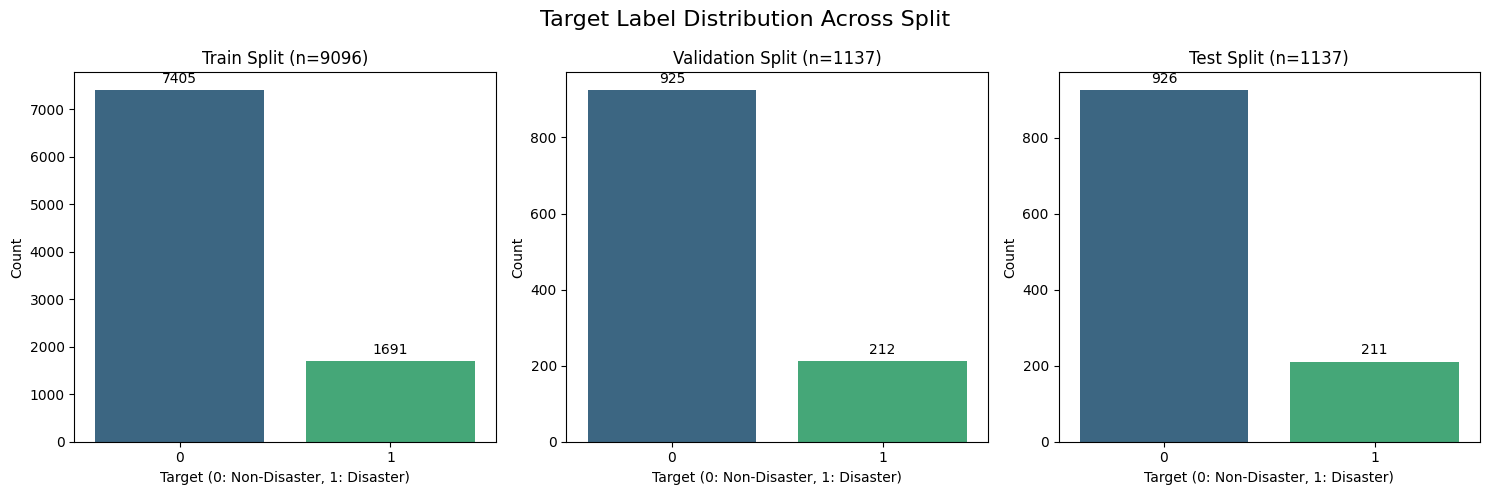

Train:
target
0    81.41
1    18.59
Name: proportion, dtype: float64
Validation:
target
0    81.35
1    18.65
Name: proportion, dtype: float64
Test:
target
0    81.44
1    18.56
Name: proportion, dtype: float64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import os


train_csv_path = "/kaggle/working/train_split.csv"
val_csv_path = "/kaggle/working/val_split.csv"
test_csv_path = "/kaggle/working/test_split.csv"

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print(f"Train saved to: {train_csv_path}")
print(f"Val saved to:   {val_csv_path}")
print(f"Test saved to:  {test_csv_path}")


def plot_label_distributions(train, val, test):

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Target Label Distribution Across Split', fontsize=16)

    def plot_split(ax, data, title):
        sns.countplot(data=data, x='target', ax=ax, palette='viridis', hue='target', legend=False)
        ax.set_title(f"{title} (n={len(data)})")
        ax.set_xlabel('Target (0: Non-Disaster, 1: Disaster)')
        ax.set_ylabel('Count')
        
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        xytext=(0, 8), 
                        textcoords='offset points')

    plot_split(axes[0], train, 'Train Split')
    plot_split(axes[1], val, 'Validation Split')
    plot_split(axes[2], test, 'Test Split')

    plt.tight_layout()
    plt.show()

    print(f"Train:\n{train['target'].value_counts(normalize=True).round(4) * 100}")
    print(f"Validation:\n{val['target'].value_counts(normalize=True).round(4) * 100}")
    print(f"Test:\n{test['target'].value_counts(normalize=True).round(4) * 100}")

plot_label_distributions(train_df, val_df, test_df)

**the plots show that our split was fair and target distribution is the same for train/val/test.**

but we also understand that we are severly unbalanced so accuracy becomes practically useless later on and we use metrics such as recall, precision , ...

Having more data with label 0, makes the gradiant of the model decide 0 is more likely, but this is not what we want. We want the model to understand the text and decide and not by frequency of data. So in our loss function we're going to give different weights for each class. therefore forcing the model to spend time analyzing the text.



**Token Embedding**

we used an Embedding layer to convert tokens into dense vectors:

Embedding:  (Batch Size, Sequence Length) -> (Batch Size, Sequence Length, Embedding Dimension)

meaning that in each batch, each token idx (for example 3) gets converted to a d_model dimension vector.

we could've also used Linear layer because functionallity is the same as Embedding but Embedding is computetionally faster (assumes input is one hot so for example [1 0 0] and istead of multiplying weights to 0's which is waste of resources, it just uses the index which is 1 to add the weight in output so O(1) )

Also, we scale up the embedding layer by the square root of d_model, because later on we will be adding positional encoding to this embedded vector, we want the words to have more importance compared to their location because it's more valuable information.

$Input = Token Embedding * \sqrt{d_{model}} + Positional Encoding$


In [12]:
import torch
import torch.nn as nn
import math
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=d_model)
        self.d_model = d_model

    def forward(self, x):

        return self.embedding(x) * math.sqrt(self.d_model)


VOCAB_SIZE = len(vocab) 
D_MODEL = 64

token_embedder = TokenEmbedding(vocab_size=VOCAB_SIZE, d_model=D_MODEL)

sample_x, sample_y = next(iter(train_loader))

print(f"Input X shape: {sample_x.shape}")

print("X (Batch Size, Sequence Length)")
print(sample_x)
print("Y (Batch Size)")
print(sample_y)

embedded_x = token_embedder(sample_x)

print(f"Embedded X shape: {embedded_x.shape}")
print(embedded_x)


Input X shape: torch.Size([32, 50])
X (Batch Size, Sequence Length)
tensor([[   3,  504,    2,  ...,    0,    0,    0],
        [   3, 1928,    2,  ...,    0,    0,    0],
        [   3,  499,    2,  ...,    0,    0,    0],
        ...,
        [   3,  404,    2,  ...,    0,    0,    0],
        [   3,  907,    2,  ...,    0,    0,    0],
        [   3,  730,    2,  ...,    0,    0,    0]])
Y (Batch Size)
tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])
Embedded X shape: torch.Size([32, 50, 64])
tensor([[[-10.9986,  -9.1028,  10.0355,  ...,   0.3112,  -0.7292,  -5.6364],
         [ 10.3365,   6.7108, -15.0800,  ...,   6.6000, -12.4836,   2.3713],
         [  8.3172, -11.6893, -15.6474,  ..., -11.5802,  19.1157,  -5.3565],
         ...,
         [-12.5913,   9.9816,  -3.8793,  ...,  -7.6514,  -0.8131,   5.6689],
         [-12.5913,   9.9816,  -3.8793,  ...,  -7.6514,  -0.8131,   5.6689],
    

In [13]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=40):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model) # (max_len, d_model)
        

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) # (max_len, 1)
        
        even_indices = torch.arange(0, d_model, 2).float()
        
        divisor = torch.exp(even_indices / d_model * math.log(10000.0))
        
        pe[:, 0::2] = torch.sin(position / divisor)
        
        pe[:, 1::2] = torch.cos(position / divisor)
        
        pe = pe.unsqueeze(0) # (1, max_len, d_model)
        
        self.register_buffer('pe', pe)

    def forward(self, x):

        seq_len = x.size(1)

        x = x + self.pe[:, :seq_len, :]
        return x

In [14]:
import torch
import torch.nn as nn
import math
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=d_model)
        self.d_model = d_model

    def forward(self, x):

        return self.embedding(x) * math.sqrt(self.d_model)


VOCAB_SIZE = len(vocab) 
D_MODEL = 64

token_embedder = TokenEmbedding(vocab_size=VOCAB_SIZE, d_model=D_MODEL)

sample_x, sample_y = next(iter(train_loader))

In [15]:
class ModelInput(nn.Module):
    def __init__(self, vocab_size, d_model, max_len=40, dropout_rate=0.1):
        super().__init__()

        self.d_model = d_model
        
        self.token_embedder = TokenEmbedding(vocab_size=vocab_size, d_model=d_model)


        self.pos_encoding = PositionalEncoding(d_model=d_model, max_len=max_len)
        
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = self.token_embedder(x)
        
        x = self.pos_encoding(x)
        
        x = self.dropout(x)
        return x


input_block = ModelInput(vocab_size=VOCAB_SIZE, d_model=D_MODEL, max_len=SEQ_MAX_LEN)

sample_x, sample_y = next(iter(train_loader))
final_input = input_block(sample_x)

print(f"Original sequence shape: {sample_x.shape}")
print(f"Final input shape: {final_input.shape}")

Original sequence shape: torch.Size([32, 50])
Final input shape: torch.Size([32, 50, 64])


all dimensions are written inside the code (I also explaned it in below markdown cell as well)

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class ScaledDotProductAttention(nn.Module):
    def forward(self, q, k, v, mask=None):

        # q, k, v : [batch_size, num_heads, seq_len, d_k]
        d_k = q.size(-1)
        

        k_transpose = k.transpose(-2, -1) # k_transpose : [batch_size, num_heads, d_k, seq_len]

        unscaled_scores = torch.matmul(q, k_transpose) # unscaled_scores : [batch_size, num_heads, seq_len, seq_len]
        
        scores = unscaled_scores / math.sqrt(d_k) # scores : [batch_size, num_heads, seq_len, seq_len]
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
            
        attention_weights = F.softmax(scores, dim=-1) # attention_weights : [batch_size, num_heads, seq_len, seq_len]
        

        output = torch.matmul(attention_weights, v) # output : [batch_size, num_heads, seq_len, d_k]
        
        return output, attention_weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads 
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        self.W_z = nn.Linear(d_model, d_model)
        
        self.attention = ScaledDotProductAttention()

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        Q = self.W_q(q)
        K = self.W_k(k)
        V = self.W_v(v)
        

        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2) # [batch_size, seq_len, d_model] -> [batch_size, seq_len, num_heads, d_k] -> [batch_size, num_heads, seq_len, d_k]
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        output, attention_weights = self.attention(Q, K, V, mask)
        
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model) # [batch_size, num_heads, seq_len, d_k] ->  [batch_size, seq_len, num_heads, d_k] -> [batch_size, seq_len, d_model]
        
        Z = self.W_z(output) # Z : [batch_size, seq_len, d_model]
        
        return Z, attention_weights

Because one of the perks of multi-head attention is that each attention can be computed parallel, we move from a `for` loop to tensor reshaping.

* $B$: Batch Size ($32$)
* $S$: Sequence Length ($40$) (this was changed to 50 when testing the effects of this parameter, though not much changed in the results. But the explanation is still the same)
* $D$: Embedding Dimension/`d_model` ($64$)
* $H$: Number of Heads ($4$)
* $d_k$: Dimension per Head ($D / H = 16$)

First, we multiply our inputs by the learned weight matrices to get our Queries, Keys, and Values.


$$Q = X W^Q$$

$$K = X W^K$$

$$V = X W^V$$


**Dimension:** $[B, S, D] \rightarrow [32, 40, 64]$


Instead of slicing the matrix using a loop, we reshape the $D$ dimension into two separate dimensions: $H$ and $d_k$.
**Dimension:** $[B, S, H, d_k] \rightarrow [32, 40, 4, 16]$

We then transpose the Sequence ($S$) and Head ($H$) dimensions.
**Dimension:** $[B, H, S, d_k] \rightarrow [32, 4, 40, 16]$

By moving the Head dimension to index 1, PyTorch's `matmul` function treats $B$ and $H$ as isolated "batch" dimensions. It will perform matrix multiplication purely on the last two dimensions ($S$ and $d_k$) for all $32 \times 4 = 128$ isolated matrices simultaneously.

We calculate the attention scores using the formula:


$$\text{Scores} = \frac{Q K^T}{\sqrt{d_k}}$$

* $Q$ shape: $[32, 4, 40, 16]$
* $K^T$ shape: $[32, 4, 16, 40]$
* **Resulting Scores:** $[32, 4, 40, 40]$


$$\text{Attention Head} = \text{softmax}(\text{Scores}) V$$

* $\text{softmax}(\text{Scores})$ shape: $[32, 4, 40, 40]$
* $V$ shape: $[32, 4, 40, 16]$
* **Resulting Attention Head:** $[32, 4, 40, 16]$


To put the heads back together, we reverse the transpose operation, bringing Sequence ($S$) back to index 1 and Head ($H$) back to index 2.
**Dimension:** $[B, S, H, d_k] \rightarrow [32, 40, 4, 16]$

We use `.view()` to flatten the $H$ and $d_k$ dimensions back into $D$ (concatenating the heads):


$$\text{Concat}(\text{head}_1, \dots, \text{head}_H)$$


**Dimension:** $[B, S, D] \rightarrow [32, 40, 64]$


$$\text{Z} = \text{Concat}(\dots) W^z$$


**Dimension:** $[32, 40, 64]$


In [20]:
NUM_HEADS = 4

multi_head_attention_layer = MultiHeadAttention(d_model=D_MODEL, num_heads=NUM_HEADS)

pad_idx = vocab.word_to_idx["<PAD>"]

# sample_x : [32, 40]
mask = (sample_x != pad_idx).unsqueeze(1).unsqueeze(2) # mask : [32, 1, 1, 40] 

print(f"Final Input shape:  {final_input.shape}")
print(f"Mask shape:  {mask.shape}")

Z, attention_weights = multi_head_attention_layer(q=final_input, k=final_input, v=final_input, mask=mask)

print(f"Attention Weights shape:    {attention_weights.shape}")


print(f"Final Output shape (Z) {Z.shape}")

Final Input shape:  torch.Size([32, 50, 64])
Mask shape:  torch.Size([32, 1, 1, 50])
Attention Weights shape:    torch.Size([32, 4, 50, 50])
Final Output shape (Z) torch.Size([32, 50, 64])


In [21]:
import torch.nn as nn

class FeedForward(nn.Module):
    def __init__(self, d_model, d_hidden=128, dropout_rate=0.1):
        super().__init__()
        
        self.linear1 = nn.Linear(d_model, d_hidden)
        
        self.relu = nn.ReLU()
        
        self.linear2 = nn.Linear(d_hidden, d_model)
        
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        
        x = self.linear1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        output = self.linear2(x)
        
        return output

In [22]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_hidden=128, dropout_rate=0.1):
        super().__init__()
        
        self.self_attention = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, d_hidden, dropout_rate)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(p=dropout_rate)
        self.dropout2 = nn.Dropout(p=dropout_rate)

    def forward(self, x, mask=None):

        Z, attention_weights = self.self_attention(q=x, k=x, v=x, mask=mask)
        
        x = self.norm1(x + self.dropout1(Z))
        
        feed_forward_output = self.feed_forward(x)
        
        output = self.norm2(x + self.dropout2(feed_forward_output))
        
        return output, attention_weights

In [23]:
D_HIDDEN = 128

encoder_block = EncoderBlock(d_model=D_MODEL, num_heads=NUM_HEADS, d_hidden=D_HIDDEN)

print(f"Input shape : {final_input.shape}")
print(f"Mask shape: {mask.shape}")

block_output, block_attention_weights = encoder_block(x=final_input, mask=mask)

print(f"Block Output shape: {block_output.shape}")

print(f"Block Attention Weights shape: {block_attention_weights.shape}")


Input shape : torch.Size([32, 50, 64])
Mask shape: torch.Size([32, 1, 1, 50])
Block Output shape: torch.Size([32, 50, 64])
Block Attention Weights shape: torch.Size([32, 4, 50, 50])


In [24]:
class TinyTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_hidden, num_encoder_blocks, num_classes=2, dropout_rate=0.1, max_len=40):
        super().__init__()
        
        self.input_block = ModelInput(vocab_size, d_model, max_len, dropout_rate)
        
        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_hidden, dropout_rate)
            for _ in range(num_encoder_blocks)
        ])
        
        self.classifier_head = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(d_hidden, num_classes)
        )

    def forward(self, x, mask=None):

        x = self.input_block(x) 

        for block in self.encoder_blocks:
            x, attention_weights = block(x, mask)
            
        cls_token_output = x[:, 0, :] 
        
        logits = self.classifier_head(cls_token_output)

        return logits, attention_weights

In [25]:
NUM_ENCODER_BLOCKS = 2

model = TinyTransformerClassifier(
    vocab_size=VOCAB_SIZE, 
    d_model=D_MODEL, 
    num_heads=NUM_HEADS, 
    d_hidden=D_HIDDEN, 
    num_encoder_blocks=NUM_ENCODER_BLOCKS,
    max_len=SEQ_MAX_LEN
)


num_class_0 = (train_Y == 0).sum().item()
num_class_1 = (train_Y == 1).sum().item()

weight_0 = 1.0 / math.sqrt(num_class_0)
weight_1 = 1.0 / math.sqrt(num_class_1)

sum_weights = weight_0 + weight_1
weight_0 = weight_0 / sum_weights
weight_1 = weight_1 / sum_weights

class_weights = torch.tensor([weight_0, weight_1], dtype=torch.float32)

print(f"Class 0 (Non-Disaster) Weight: {weight_0:.4f}")
print(f"Class 1 (Disaster) Weight:     {weight_1:.4f}")


criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

Class 0 (Non-Disaster) Weight: 0.3234
Class 1 (Disaster) Weight:     0.6766


In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from tqdm.notebook import tqdm 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

model = model.to(device)
criterion = criterion.to(device)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

EPOCHS = 30


best_val_loss = float('inf')


for epoch in range(EPOCHS):

    model.train()
    train_total_loss = 0
    train_preds, train_true = [], []
    
    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).long() 
        
        optimizer.zero_grad() 
        
        logits, _ = model(batch_x) 
        
        loss = criterion(logits, batch_y)
        train_total_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_true.extend(batch_y.cpu().numpy())
        
    avg_train_loss = train_total_loss / len(train_loader)
    train_acc = accuracy_score(train_true, train_preds)
    

    model.eval() 
    val_total_loss = 0
    val_preds, val_true = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device).long()
            
            logits, _ = model(batch_x)
            loss = criterion(logits, batch_y)
            val_total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(batch_y.cpu().numpy())
            
    avg_val_loss = val_total_loss / len(val_loader)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'tiny_transformer.pt')
        print(f"model saved (best results in epoch {epoch})")

    val_acc = accuracy_score(val_true, val_preds)
    
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")


model saved (best results in epoch 3)
Epoch 4 | Train Loss: 0.6234 | Train Acc: 0.7924 | Val Loss: 0.6191 | Val Acc: 0.7353


Epoch 5/30 [Train]:   0%|          | 0/285 [00:00<?, ?it/s]

model saved (best results in epoch 4)
Epoch 5 | Train Loss: 0.6035 | Train Acc: 0.8010 | Val Loss: 0.5935 | Val Acc: 0.7951


Epoch 6/30 [Train]:   0%|          | 0/285 [00:00<?, ?it/s]

Epoch 6 | Train Loss: 0.5837 | Train Acc: 0.8149 | Val Loss: 0.5968 | Val Acc: 0.7889


...

Epoch 28 | Train Loss: 0.4488 | Train Acc: 0.9037 | Val Loss: 0.5845 | Val Acc: 0.8434


Epoch 29/30 [Train]:   0%|          | 0/285 [00:00<?, ?it/s]

Epoch 29 | Train Loss: 0.4425 | Train Acc: 0.9103 | Val Loss: 0.6024 | Val Acc: 0.8223


Epoch 30/30 [Train]:   0%|          | 0/285 [00:00<?, ?it/s]

Epoch 30 | Train Loss: 0.4405 | Train Acc: 0.9100 | Val Loss: 0.5882 | Val Acc: 0.8364


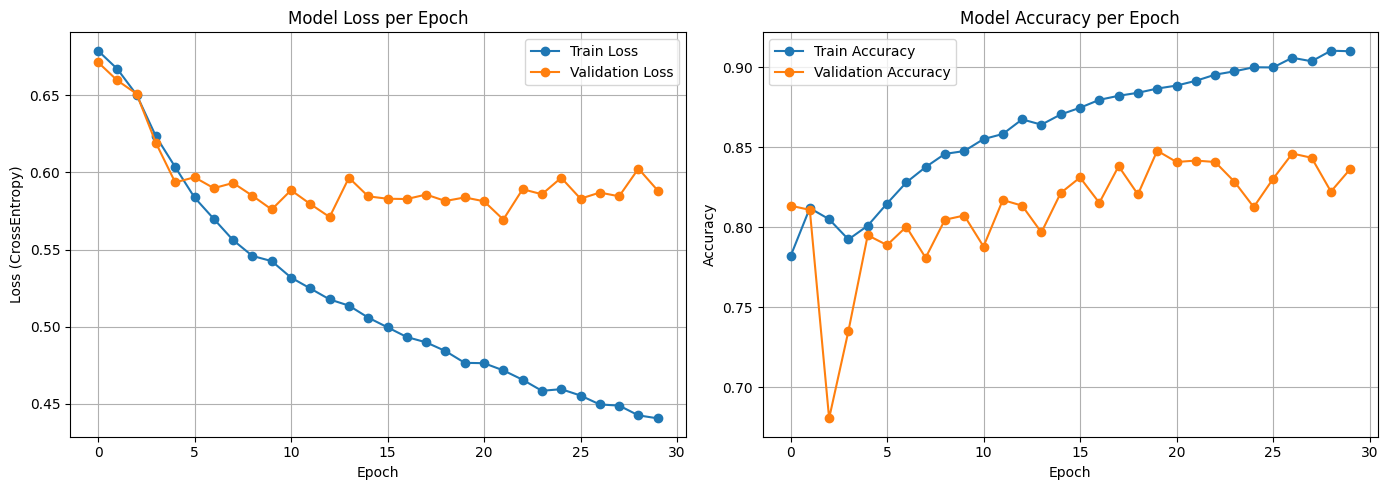

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Validation Loss', marker='o')
axes[0].set_title('Model Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (CrossEntropy)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='o')
axes[1].set_title('Model Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Validation Set Evaluation
Accuracy:  0.8417
Precision: 0.5690
Recall:    0.6226
F1-score:  0.5946



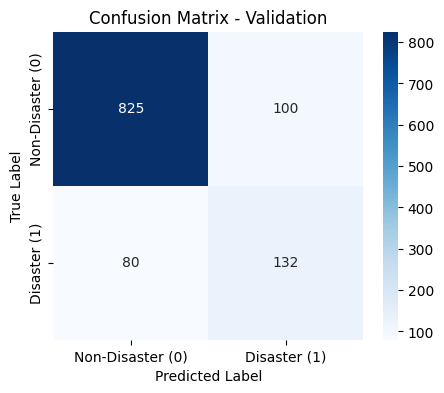

Test Set Evaluation
Accuracy:  0.8347
Precision: 0.5466
Recall:    0.6398
F1-score:  0.5895



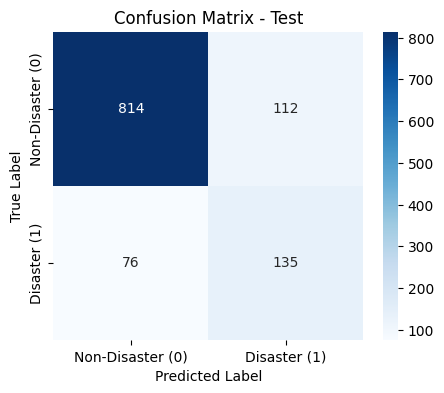

In [31]:
from sklearn.metrics import precision_recall_fscore_support

model.load_state_dict(torch.load('tiny_transformer.pt'))
model.eval()

def evaluate_best_model(dataloader, dataset_name):
    true_labels = []
    all_preds = []
    
    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device).long()
            
            logits, _ = model(batch_x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            true_labels.extend(batch_y.cpu().numpy())
            
    acc = accuracy_score(true_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, all_preds, average='binary', zero_division=0
    )
    cm = confusion_matrix(true_labels, all_preds)
    
    print(f"{dataset_name} Set Evaluation")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}\n")
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Disaster (0)', 'Disaster (1)'], 
                yticklabels=['Non-Disaster (0)', 'Disaster (1)'])
    plt.title(f'Confusion Matrix - {dataset_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

evaluate_best_model(val_loader, "Validation")
evaluate_best_model(test_loader, "Test")

In [33]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class BERTDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64):

        self.keywords = df['keyword'].fillna('').values
        self.texts = df['clean_text'].fillna('').values
        self.labels = df['target'].values
        
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        keyword = str(self.keywords[idx])
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            keyword,                 
            text,                       
            add_special_tokens=True, 
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

MAX_LEN_BERT = 64
BATCH_SIZE_BERT = 32

bert_train_dataset = BERTDataset(train_df, tokenizer, MAX_LEN_BERT)
bert_val_dataset = BERTDataset(val_df, tokenizer, MAX_LEN_BERT)
bert_test_dataset = BERTDataset(test_df, tokenizer, MAX_LEN_BERT)

bert_train_loader = DataLoader(bert_train_dataset, batch_size=BATCH_SIZE_BERT, shuffle=True)
bert_val_loader = DataLoader(bert_val_dataset, batch_size=BATCH_SIZE_BERT, shuffle=False)
bert_test_loader = DataLoader(bert_test_dataset, batch_size=BATCH_SIZE_BERT, shuffle=False)

sample = next(iter(bert_train_loader))
print("Input IDs shape:", sample['input_ids'].shape)
print("Attention Mask shape:", sample['attention_mask'].shape)
print("Labels shape:", sample['labels'].shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Input IDs shape: torch.Size([32, 64])
Attention Mask shape: torch.Size([32, 64])
Labels shape: torch.Size([32])


In [34]:
from transformers import BertForSequenceClassification
from torch.optim import AdamW

model_bert = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', 
    num_labels=2
)


for param in model_bert.bert.parameters():
    param.requires_grad = False


total_params = sum(p.numel() for p in model_bert.parameters())
trainable_params = sum(p.numel() for p in model_bert.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,} (Only for the classification head)")

model_bert = model_bert.to(device)

optimizer_bert = AdamW(model_bert.classifier.parameters(), lr=2e-3) 

EPOCHS_BERT = 5

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Parameters: 109,483,778
Trainable Parameters: 1,538 (Only for the classification head)


In [35]:
for epoch in range(EPOCHS_BERT):
    model_bert.train()
    train_loss = 0
    
    for batch in bert_train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer_bert.zero_grad()
        
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        loss = criterion(logits, labels)
        train_loss += loss.item()
        
        loss.backward()
        optimizer_bert.step()
        
    print(f"Epoch {epoch+1}/{EPOCHS_BERT} | Loss: {train_loss/len(bert_train_loader):.4f}")

Epoch 1/5 | Loss: 0.5983
Epoch 2/5 | Loss: 0.5642
Epoch 3/5 | Loss: 0.5584
Epoch 4/5 | Loss: 0.5541
Epoch 5/5 | Loss: 0.5560



 BERT Validation Evaluation
Accuracy:  0.8619
Precision: 0.6355
Recall:    0.6085
F1-score:  0.6217

 BERT Test Evaluation
Accuracy:  0.8619
Precision: 0.6174
Recall:    0.6730
F1-score:  0.6440


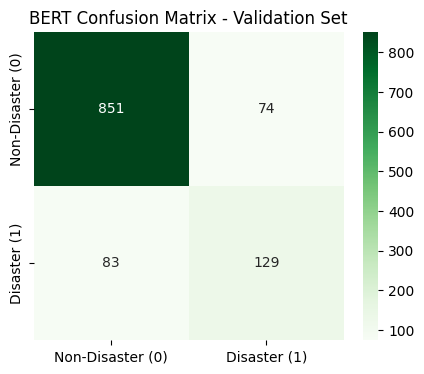

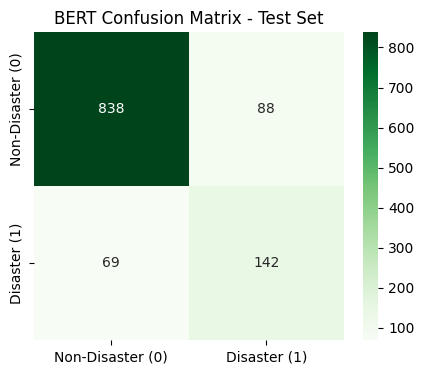

In [37]:
def evaluate_bert(dataloader, dataset_name):
    model_bert.eval()
    true_labels = []
    all_preds = []
    all_texts = [] 
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            true_labels.extend(labels.cpu().numpy())
            
            for ids in input_ids:
                all_texts.append(tokenizer.decode(ids, skip_special_tokens=True))
            
    acc = accuracy_score(true_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, all_preds, average='binary', zero_division=0
    )
    
    print(f"\n BERT {dataset_name} Evaluation")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    
    return all_preds, true_labels, all_texts

val_preds_bert, val_true_bert, _ = evaluate_bert(bert_val_loader, "Validation")
test_preds_bert, test_true_bert, test_texts_bert = evaluate_bert(bert_test_loader, "Test")

cm_val_bert = confusion_matrix(val_true_bert, val_preds_bert)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_val_bert, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-Disaster (0)', 'Disaster (1)'], 
            yticklabels=['Non-Disaster (0)', 'Disaster (1)'])
plt.title('BERT Confusion Matrix - Validation Set')
plt.show()

cm_test_bert = confusion_matrix(test_true_bert, test_preds_bert)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_test_bert, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-Disaster (0)', 'Disaster (1)'], 
            yticklabels=['Non-Disaster (0)', 'Disaster (1)'])
plt.title('BERT Confusion Matrix - Test Set')
plt.show()



In [38]:
model.eval()
test_preds_tiny = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        logits, _ = model(batch_x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        test_preds_tiny.extend(preds)

bert_right_tiny_wrong = []
tiny_right_bert_wrong = []

for i in range(len(test_true_bert)):
    true_lbl = test_true_bert[i]
    pred_bert = test_preds_bert[i]
    pred_tiny = test_preds_tiny[i]
    
    if pred_bert == true_lbl and pred_tiny != true_lbl:
        bert_right_tiny_wrong.append(i)
    elif pred_tiny == true_lbl and pred_bert != true_lbl:
        tiny_right_bert_wrong.append(i)

print(f"Number of samples BERT got right but Tiny didn't: {len(bert_right_tiny_wrong)}")
print(f"Number of samples Tiny got right but BERT didn't: {len(tiny_right_bert_wrong)}")

print("Sample (BERT is Correct, Tiny is Wrong)")
if bert_right_tiny_wrong:
    idx = bert_right_tiny_wrong[0]
    print(f"Text: {test_texts_bert[idx]}")
    print(f"True Label: {test_true_bert[idx]}")
    print(f"BERT Prediction: {test_preds_bert[idx]}")
    print(f"Tiny Prediction: {test_preds_tiny[idx]}")

print("Sample(Tiny is Correct, BERT is Wrong)")
if tiny_right_bert_wrong:
    idx = tiny_right_bert_wrong[0]
    print(f"Text: {test_texts_bert[idx]}")
    print(f"True Label: {test_true_bert[idx]}")
    print(f"BERT Prediction: {test_preds_bert[idx]}")
    print(f"Tiny Prediction: {test_preds_tiny[idx]}")

Number of samples BERT got right but Tiny didn't: 114
Number of samples Tiny got right but BERT didn't: 83
Sample (BERT is Correct, Tiny is Wrong)
Text: damage emergency closure moray college uhi fully closed staff students tuesday 14th january due storm
True Label: 1
BERT Prediction: 1
Tiny Prediction: 0
Sample(Tiny is Correct, BERT is Wrong)
Text: military trump divert extra 7 2 billion military border wall reports say
True Label: 0
BERT Prediction: 1
Tiny Prediction: 0


**Positional Encoding (To have or not to have?)**

In [41]:
class ModelInputNoPE(nn.Module):
    def __init__(self, vocab_size, d_model, dropout_rate=0.1):
        super().__init__()
        self.d_model = d_model
        self.token_embedder = TokenEmbedding(vocab_size=vocab_size, d_model=d_model)
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = self.token_embedder(x)
                
        x = self.dropout(x)
        return x

class TinyTransformerClassifierNoPE(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_hidden, num_encoder_blocks, num_classes=2, dropout_rate=0.1):
        super().__init__()
        
        self.input_block = ModelInputNoPE(vocab_size, d_model, dropout_rate)
        
        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_hidden, dropout_rate)
            for _ in range(num_encoder_blocks)
        ])
        
        self.classifier_head = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(d_hidden, num_classes)
        )

    def forward(self, x, mask=None):
        x = self.input_block(x) 
        for block in self.encoder_blocks:
            x, attention_weights = block(x, mask)
            
        cls_token_output = x[:, 0, :] 
        logits = self.classifier_head(cls_token_output)
        return logits, attention_weights

model_no_pe = TinyTransformerClassifierNoPE(
    vocab_size=VOCAB_SIZE, 
    d_model=D_MODEL, 
    num_heads=NUM_HEADS, 
    d_hidden=D_HIDDEN, 
    num_encoder_blocks=NUM_ENCODER_BLOCKS
).to(device)

optimizer_no_pe = torch.optim.Adam(model_no_pe.parameters(), lr=1e-4, weight_decay=1e-5)
best_val_loss_no_pe = float('inf')

for epoch in range(EPOCHS):
    model_no_pe.train()
    train_total_loss = 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
        optimizer_no_pe.zero_grad() 
        logits, _ = model_no_pe(batch_x) 
        
        loss = criterion(logits, batch_y)
        train_total_loss += loss.item()
        
        loss.backward()
        optimizer_no_pe.step()
        
    model_no_pe.eval() 
    val_total_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
            logits, _ = model_no_pe(batch_x)
            loss = criterion(logits, batch_y)
            val_total_loss += loss.item()
            
    avg_val_loss = val_total_loss / len(val_loader)
    
    if avg_val_loss < best_val_loss_no_pe:
        best_val_loss_no_pe = avg_val_loss
        torch.save(model_no_pe.state_dict(), 'tiny_transformer_no_pe.pt')

print("Best model saved (without positional encoding).")

Best model saved (without positional encoding).


In [42]:
model_no_pe.load_state_dict(torch.load('tiny_transformer_no_pe.pt'))
model_no_pe.eval()
def evaluate_model_no_pe(dataloader, dataset_name):
    true_labels, all_preds = [], []
    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
            logits, _ = model_no_pe(batch_x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            true_labels.extend(batch_y.cpu().numpy())
            
    acc = accuracy_score(true_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, all_preds, average='binary', zero_division=0)
    
    print(f"{dataset_name} Set Evaluation (NO PE)")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

evaluate_model_no_pe(val_loader, "Validation")
evaluate_model_no_pe(test_loader, "Test")

Validation Set Evaluation (NO PE)
Accuracy:  0.8303
Precision: 0.5375
Recall:    0.6415
F1-score:  0.5849
Test Set Evaluation (NO PE)
Accuracy:  0.8215
Precision: 0.5159
Recall:    0.6161
F1-score:  0.5616



Training BERT with 2 HEADS (Fine-tuning)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Loss: 0.5449
Epoch 2/3 | Loss: 0.4657
Epoch 3/3 | Loss: 0.4193
Evaluating BERT (2 Heads) on Test Set...
--- BERT Test Results (2 Heads) ---
Accuracy:  0.8751
Precision: 0.6255
Recall:    0.8152
F1-score:  0.7078

Training BERT with 8 HEADS (Fine-tuning)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Loss: 0.5103
Epoch 2/3 | Loss: 0.4173
Epoch 3/3 | Loss: 0.3598
Evaluating BERT (8 Heads) on Test Set...
--- BERT Test Results (8 Heads) ---
Accuracy:  0.8857
Precision: 0.6601
Recall:    0.7915
F1-score:  0.7198


In [45]:
head_configs = [2, 8]
results_heads = {}

for h in head_configs:
    print(f"Training Tiny Transformer with {h} HEADS")
    
    model_h = TinyTransformerClassifier(
        vocab_size=VOCAB_SIZE, 
        d_model=D_MODEL, 
        num_heads=h, 
        d_hidden=D_HIDDEN, 
        num_encoder_blocks=NUM_ENCODER_BLOCKS,
        max_len=SEQ_MAX_LEN
    ).to(device)
    
    optimizer_h = torch.optim.Adam(model_h.parameters(), lr=1e-4, weight_decay=1e-5)
    best_val_loss_h = float('inf')
    best_model_path = f'tiny_transformer_{h}heads.pt'
    
    for epoch in range(25): 
        model_h.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
            optimizer_h.zero_grad()
            logits, _ = model_h(batch_x)
            loss = criterion(logits, batch_y)
            train_loss += loss.item()
            loss.backward()
            optimizer_h.step()
            
        model_h.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
                logits, _ = model_h(batch_x)
                loss = criterion(logits, batch_y)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        if avg_val_loss < best_val_loss_h:
            best_val_loss_h = avg_val_loss
            torch.save(model_h.state_dict(), best_model_path)
        print(f"epoch {epoch} finished.")
            
    
    model_h.load_state_dict(torch.load(best_model_path))
    model_h.eval()
    
    test_preds, test_true = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
            logits, _ = model_h(batch_x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            test_preds.extend(preds)
            test_true.extend(batch_y.cpu().numpy())
            
    acc = accuracy_score(test_true, test_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(test_true, test_preds, average='binary', zero_division=0)
    
    results_heads[h] = {'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1': f1}
    
    print(f"--- Test Results ({h} Heads) ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

Training Tiny Transformer with 2 HEADS
epoch 0 finished.
epoch 1 finished.
epoch 2 finished.
epoch 3 finished.
epoch 4 finished.
epoch 5 finished.
epoch 6 finished.
epoch 7 finished.
epoch 8 finished.
epoch 9 finished.
epoch 10 finished.
epoch 11 finished.
epoch 12 finished.
epoch 13 finished.
epoch 14 finished.
epoch 15 finished.
epoch 16 finished.
epoch 17 finished.
epoch 18 finished.
epoch 19 finished.
epoch 20 finished.
epoch 21 finished.
epoch 22 finished.
epoch 23 finished.
epoch 24 finished.
--- Test Results (2 Heads) ---
Accuracy:  0.8470
Precision: 0.5920
Recall:    0.5640
F1-score:  0.5777
Training Tiny Transformer with 8 HEADS
epoch 0 finished.
epoch 1 finished.
epoch 2 finished.
epoch 3 finished.
epoch 4 finished.
epoch 5 finished.
epoch 6 finished.
epoch 7 finished.
epoch 8 finished.
epoch 9 finished.
epoch 10 finished.
epoch 11 finished.
epoch 12 finished.
epoch 13 finished.
epoch 14 finished.
epoch 15 finished.
epoch 16 finished.
epoch 17 finished.
epoch 18 finished.
epo

In [46]:
from transformers import BertConfig, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch

head_configs = [2, 8]
results_bert_heads = {}


for h in head_configs:
    print(f"Training BERT with {h} HEADS")
    
    config = BertConfig.from_pretrained('bert-base-uncased', num_labels=2, num_attention_heads=h)
    
    model_bert_h = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', 
        config=config, 
        ignore_mismatched_sizes=False
    ).to(device)
    
    optimizer_bert_h = AdamW(model_bert_h.parameters(), lr=2e-5)
        
    for epoch in range(3):
        model_bert_h.train()
        train_loss = 0
        
        for batch in bert_train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer_bert_h.zero_grad()
            outputs = model_bert_h(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            train_loss += loss.item()
            
            loss.backward()
            optimizer_bert_h.step()
            
        print(f"epoch {epoch} finished")
        
    model_bert_h.eval()
    test_preds, test_true = [], []
    
    with torch.no_grad():
        for batch in bert_test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model_bert_h(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            
            test_preds.extend(preds)
            test_true.extend(labels.cpu().numpy())
            
    acc = accuracy_score(test_true, test_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(test_true, test_preds, average='binary', zero_division=0)
    
    results_bert_heads[h] = {'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1': f1}
    
    print(f"--- BERT Test Results ({h} Heads) ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

Training BERT with 2 HEADS


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


epoch 0 finished
epoch 1 finished
epoch 2 finished
--- BERT Test Results (2 Heads) ---
Accuracy:  0.8056
Precision: 0.4868
Recall:    0.8720
F1-score:  0.6248
Training BERT with 8 HEADS


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


epoch 0 finished
epoch 1 finished
epoch 2 finished
--- BERT Test Results (8 Heads) ---
Accuracy:  0.8962
Precision: 0.7360
Recall:    0.6872
F1-score:  0.7108


Plotting Attention:
[CLS] damage [SEP] emergency closure moray college uhi fully closed staff students tuesday 14th january due storm


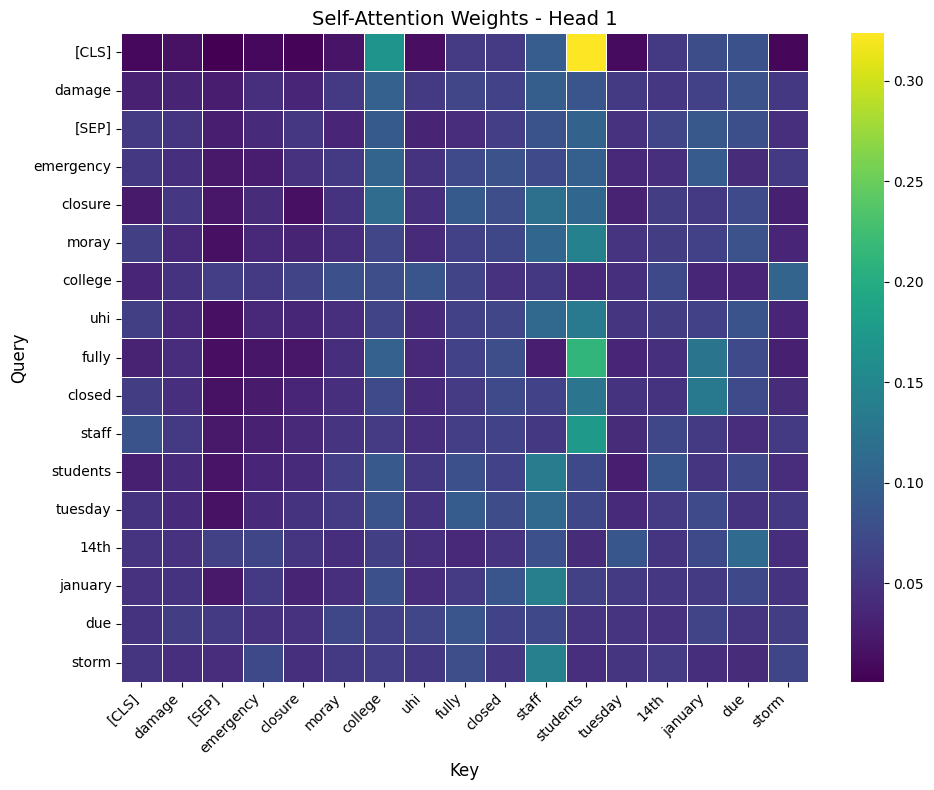

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

model.load_state_dict(torch.load('tiny_transformer.pt'))
model.eval()

def plot_attention(model, vocab, final_text_str, head_idx=0):

    input_words = str(final_text_str).split()
    
    if len(input_words) > 30: 
        input_words = input_words[:30]
        
    x = [vocab.word_to_idx.get(w, vocab.word_to_idx["<UNK>"]) for w in input_words]
    x_tensor = torch.tensor([x]).to(device)
    
    with torch.no_grad():
        _, attention_weights = model(x_tensor)
        

    attn_matrix = attention_weights[0, head_idx].cpu().numpy()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(attn_matrix, 
                xticklabels=input_words, 
                yticklabels=input_words, 
                cmap='viridis', 
                linewidths=0.5)
    
    plt.title(f'Self-Attention Weights - Head {head_idx+1}', fontsize=14)
    plt.xlabel('Key', fontsize=12)
    plt.ylabel('Query', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()


sample_row = test_df[test_df['target'] == 1].iloc[0]
sample_final_text = sample_row['final_text']

print(f"Plotting Attention:\n{sample_final_text}")

plot_attention(model, vocab, sample_final_text, head_idx=0)